# 🔊 Broadband Processing Theory

Understanding how to process and beamform wideband signals like chirps or coded pulses.

## 🔹 1. Introduction
In narrowband systems, we assume a single frequency — delays result in phase shifts.
In broadband systems, signals span multiple frequencies — delays cause more complex effects.

## 🔹 2. Broadband Signal Example: Chirp
We simulate a linear frequency modulated (LFM) chirp signal.

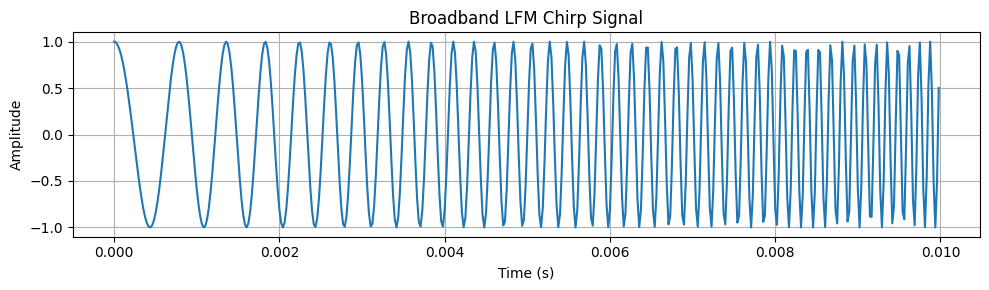

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 48000
duration = 0.01
f0 = 1000
f1 = 8000
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# Generate chirp
k = (f1 - f0) / duration
chirp = np.cos(2 * np.pi * (f0 * t + 0.5 * k * t**2))

# Plot
plt.figure(figsize=(10, 3))
plt.plot(t, chirp)
plt.title("Broadband LFM Chirp Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 3. Apply Time Delay to Each Sensor
We'll simulate an 8-element array receiving the chirp from a 45° direction of arrival (DOA).

In [2]:
def create_broadband_array_signals(signal, fs, num_elements, doa_deg, d=0.015, c=1500):
    theta = np.radians(doa_deg)
    delayed_signals = []
    for n in range(num_elements):
        delay_sec = (n * d * np.sin(theta)) / c
        delay_samples = int(np.round(delay_sec * fs))
        shifted = np.roll(signal, delay_samples)
        delayed_signals.append(shifted)
    return np.array(delayed_signals)

array_signals = create_broadband_array_signals(chirp, fs, 8, 45)

## 🔹 4. Compare Narrowband vs Broadband Beamforming
In narrowband, we use phase shifts; in broadband, we must time-align each element.

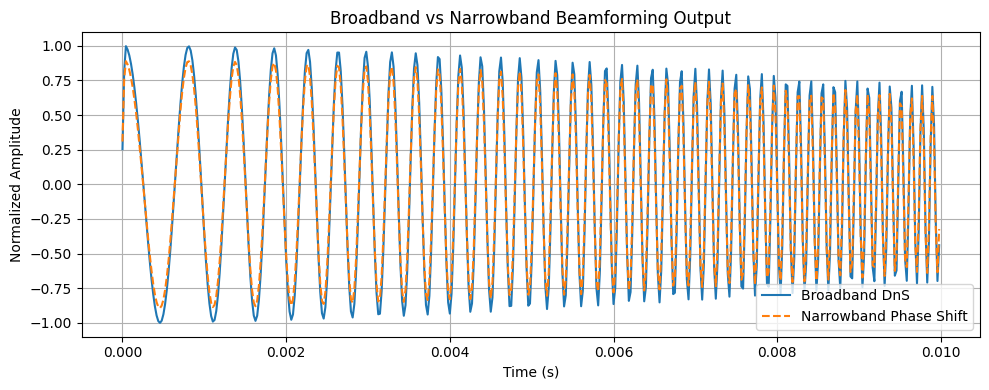

In [3]:
# Narrowband steering: apply phase shift
def narrowband_steering_vector(N, d, wavelength, theta_deg):
    theta_rad = np.radians(theta_deg)
    n = np.arange(N)
    return np.exp(-1j * 2 * np.pi * d * n * np.sin(theta_rad) / wavelength)

# Apply narrowband steering
wavelength = 1500 / 3000  # assume center freq 3kHz
sv = narrowband_steering_vector(8, 0.015, wavelength, 45)
narrowband_output = np.dot(sv.conj().T, array_signals)

# Broadband: simple delay-and-sum
broadband_output = np.sum(array_signals, axis=0)

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(t, broadband_output / np.max(np.abs(broadband_output)), label="Broadband DnS")
plt.plot(t, narrowband_output.real / np.max(np.abs(narrowband_output)), '--', label="Narrowband Phase Shift")
plt.legend()
plt.title("Broadband vs Narrowband Beamforming Output")
plt.xlabel("Time (s)")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

## ✅ Summary
- Narrowband assumes phase-only shifts → fast but inaccurate for wideband
- Broadband needs real delays → time alignment before summation
- Subband methods can approximate broadband with narrowband tools